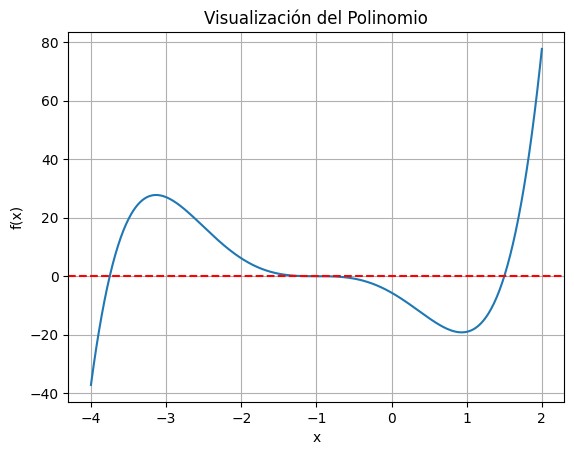

--- Buscando raíces con scipy.optimize.bisect ---
Raíz encontrada en el intervalo [-1.2, -0.5]: -1.0000
Raíz encontrada en el intervalo [1, 2]: 1.5000

--- Buscando/Refinando raíces con scipy.optimize.newton ---
Raíz hallada con estimación inicial x0=-2.5: -1.0000
Raíz hallada con estimación inicial x0=-1.5: -1.0000
Raíz hallada con estimación inicial x0=-1.0: -1.0000
Raíz hallada con estimación inicial x0=1.5: 1.5000

--- Conjunto final de raíces únicas encontradas ---
[-1.0, 1.5]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect, newton

# 1. Definir la función polinómica
def f(x):
    return x**5 + 5.25*x**4 + 4.125*x**3 - 9.125*x**2 - 14.625*x - 5.625

# 2. Derivada de la función 
def df(x):
    return 5*x**4 + 21*x**3 + 12.375*x**2 - 18.25*x - 14.625

# Visualización 
x_vals = np.linspace(-4, 2, 500)
y_vals = f(x_vals)

plt.plot(x_vals, y_vals, label="f(x)")
plt.axhline(0, color='red', linestyle='--')
plt.title("Visualización del Polinomio")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

# 3. Cálculo de raíces basándonos en el comportamiento del polinomio
# Al analizar el polinomio, se identifican cambios de signo o raíces múltiples.
raices = set()

# Intentamos hallar las raíces usando bisección en intervalos donde hay cambio de signo
intervalos = [(-3, -2), (-2, -1.2), (-1.2, -0.5), (1, 2)]

print("--- Buscando raíces con scipy.optimize.bisect ---")
for a, b in intervalos:
    try:
        raiz = bisect(f, a, b, xtol=1e-6)
        raices.add(round(raiz, 4))
        print(f"Raíz encontrada en el intervalo [{a}, {b}]: {raiz:.4f}")
    except ValueError:
        # Si no hay cambio de signo en el intervalo dado
        pass

# Intentamos hallar raíces restantes (o multiplicidades) con el método de Newton
print("\n--- Buscando/Refinando raíces con scipy.optimize.newton ---")
estimaciones_iniciales = [-2.5, -1.5, -1.0, 1.5]

for x0 in estimaciones_iniciales:
    try:
        # Se pasa df para usar Newton-Raphson estándar. 
        # Si no se pasa df, SciPy usa el método de la secante de forma automática.
        raiz = newton(f, x0, fprime=df, tol=1e-6)
        raices.add(round(raiz, 4))
        print(f"Raíz hallada con estimación inicial x0={x0}: {raiz:.4f}")
    except RuntimeError:
        print(f"El método de Newton no convergió para x0={x0}")

print("\n--- Conjunto final de raíces únicas encontradas ---")
print(sorted(list(raices)))